In [55]:
import pandas as pd
df = pd.read_csv('Sentimen_Cleaned.csv')
df.head()

,Response,Submitted on,Kritik dan saran,Sentimen,tanggal,jam,hari,normalisasi,case_folding,tokenizing,filtering,stemming,clean_review,Sentimen_Biner
0,345836,2025-09-21 01:06:00,Untuk servernya full dan error jadi agak susah...,negatif,2025-09-21,1,Sunday,Untuk servernya full dan error jadi agak susah...,untuk servernya full dan error jadi agak susah...,"['untuk', 'servernya', 'full', 'dan', 'error',...","['servernya', 'full', 'error', 'jadi', 'susah'...","['servernya', 'full', 'error', 'jadi', 'susah'...",servernya full error jadi susah kerja,-1
1,306420,2025-09-17 23:02:00,Sudah baik untuk tahun ini namun akan lebih ba...,positif,2025-09-17,23,Wednesday,Sudah baik untuk tahun ini namun akan lebih ba...,sudah baik untuk tahun ini namun akan lebih ba...,"['sudah', 'baik', 'untuk', 'tahun', 'ini', 'na...","['baik', 'tahun', 'lebih', 'baik', 'laksanakan...","['baik', 'tahun', 'lebih', 'baik', 'laksana', ...",baik tahun lebih baik laksana langsung terima ...,1
2,341608,2025-09-20 18:47:00,Tolong perbaiki website PPKMB sehingga lebih m...,positif,2025-09-20,18,Saturday,Tolong perbaiki website PPKMB sehingga lebih m...,tolong perbaiki website ppkmb sehingga lebih m...,"['tolong', 'perbaiki', 'website', 'ppkmb', 'se...","['perbaiki', 'website', 'ppkmb', 'lebih', 'mud...","['baik', 'website', 'ppkmb', 'lebih', 'mudah',...",baik website ppkmb lebih mudah cepat akses,1
3,293208,2025-09-15 20:21:00,Kegiatan PKKMB tahun ini menurut saya sudah be...,positif,2025-09-15,20,Monday,Kegiatan PKKMB tahun ini menurut saya sudah be...,kegiatan pkkmb tahun ini menurut saya sudah be...,"['kegiatan', 'pkkmb', 'tahun', 'ini', 'menurut...","['kegiatan', 'pkkmb', 'tahun', 'berjalan', 'ba...","['giat', 'pkkmb', 'tahun', 'jalan', 'baik', 'b...",giat pkkmb tahun jalan baik beri banyak inform...,1
4,341272,2025-09-20 18:06:00,Semoga lebih baik,positif,2025-09-20,18,Saturday,Semoga lebih baik,semoga lebih baik,"['semoga', 'lebih', 'baik']","['semoga', 'lebih', 'baik']","['moga', 'lebih', 'baik']",moga lebih baik,1


In [56]:
df = df[['Kritik dan saran', 'Sentimen']]
df.columns = ['text', 'label']
df.head()

,text,label
0,Untuk servernya full dan error jadi agak susah...,negatif
1,Sudah baik untuk tahun ini namun akan lebih ba...,positif
2,Tolong perbaiki website PPKMB sehingga lebih m...,positif
3,Kegiatan PKKMB tahun ini menurut saya sudah be...,positif
4,Semoga lebih baik,positif


In [57]:
df.info()
df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8025 entries, 0 to 8024
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    8025 non-null   object
 1   label   8025 non-null   object
dtypes: object(2)
memory usage: 125.5+ KB


,count
label,
positif,4126
netral,2703
negatif,1196


In [58]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [59]:
import re

slang_dict = {
    "gk": "tidak", "ga": "tidak", "bgt": "banget",
    "yg": "yang",  "dgn": "dengan", "utk": "untuk",
    "krn": "karena", "sdh": "sudah", "blm": "belum",
    "jg": "juga",  "lg": "lagi",   "tp": "tapi",
    "gak": "tidak", "nggak": "tidak", "gpp": "tidak apa",
    "mksh": "terima kasih", "tks": "terima kasih",
}

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = ' '.join([slang_dict.get(w, w) for w in text.split()])
    return text

df['clean_text'] = df['text'].apply(clean_text)
df.head()

,text,label,clean_text
0,Untuk servernya full dan error jadi agak susah...,negatif,untuk servernya full dan error jadi agak susah...
1,Sudah baik untuk tahun ini namun akan lebih ba...,positif,sudah baik untuk tahun ini namun akan lebih ba...
2,Tolong perbaiki website PPKMB sehingga lebih m...,positif,tolong perbaiki website ppkmb sehingga lebih m...
3,Kegiatan PKKMB tahun ini menurut saya sudah be...,positif,kegiatan pkkmb tahun ini menurut saya sudah be...
4,Semoga lebih baik,positif,semoga lebih baik


In [60]:
!pip install Sastrawi

In [61]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopwords = factory.get_stop_words()

def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stopwords])

df['clean_text'] = df['clean_text'].apply(remove_stopwords)

In [62]:
label_map = {
    'negatif': 0,
    'netral': 1,
    'positif': 2
}

df['label'] = df['label'].map(label_map)
df['label'].value_counts()

,count
label,
2,4126
1,2703
0,1196


In [63]:
df['label'].value_counts(normalize=True)

,proportion
label,
2,0.514143
1,0.336822
0,0.149034


In [64]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [65]:
print("Sample clean_text:")
print(df['clean_text'].head(3).tolist())

Sample clean_text:
['servernya full error jadi susah mengerjakan', 'baik tahun lebih baik laksanakan langsung makasih banyak', 'perbaiki website ppkmb lebih mudah cepat diakses']


In [66]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

In [67]:
max_vocab = 10000
max_len = 100

In [68]:
vectorizer = TextVectorization(
    max_tokens=max_vocab,
    output_mode='int',
    output_sequence_length=max_len
)

In [69]:
vectorizer.adapt(X_train)

In [70]:
import json
import numpy as np

vectorizer_export = {
    "config": vectorizer.get_config(),
    "weights": [w.tolist() for w in vectorizer.get_weights()]
}

with open("vectorizer_config.json", "w") as f:
    json.dump(vectorizer_export, f)

print("Vectorizer berhasil disimpan ke: vectorizer_config.json")

Vectorizer berhasil disimpan ke: vectorizer_config.json


In [71]:
sample = ["servernya full error"]
vectorizer(sample)

<tf.Tensor: shape=(1, 100), dtype=int64, numpy=
array([[367, 886, 126,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0]])>

In [72]:
X_train_vec = vectorizer(X_train)
X_val_vec = vectorizer(X_val)

In [73]:
X_train_vec.shape

TensorShape([6420, 100])

In [74]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name="attention_weight",
            shape=(input_shape[-1], 1),
            initializer="random_normal",
            trainable=True
        )

        self.b = self.add_weight(
            name="attention_bias",
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )

    def call(self, inputs):
        score = tf.nn.tanh(
            tf.tensordot(inputs, self.W, axes=1) + self.b
        )

        attention_weights = tf.nn.softmax(score, axis=1)

        context_vector = attention_weights * inputs
        context_vector = tf.reduce_sum(context_vector, axis=1)

        return context_vector

In [75]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=y_train
)
class_weights = {i: w for i, w in enumerate(class_weights_array)}
print("Class weights:", class_weights)

class WeightedSparseCCE(tf.keras.losses.Loss):
    def __init__(self, class_weights, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = tf.constant(
            [class_weights[i] for i in sorted(class_weights)],
            dtype=tf.float32
        )

    def call(self, y_true, y_pred):
        cce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        y_true_int = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        sample_weights = tf.gather(self.class_weights, y_true_int)
        return tf.reduce_mean(sample_weights * cce)

    def get_config(self):
        config = super().get_config()
        config.update({"class_weights": {i: float(w) for i, w in enumerate(self.class_weights.numpy())}})
        return config

weighted_loss = WeightedSparseCCE(class_weights)

Class weights: {0: np.float64(2.2361546499477534), 1: np.float64(0.9898242368177613), 2: np.float64(0.6482883974553165)}


In [76]:
class DetailedLoggingCallback(tf.keras.callbacks.Callback):
    """Custom callback: log per-epoch metrics + deteksi overfitting."""

    def on_train_begin(self, logs=None):
        print("=" * 55)
        print("  Training Dimulai")
        print("=" * 55)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        train_acc = logs.get('accuracy', 0)
        val_acc   = logs.get('val_accuracy', 0)
        train_loss = logs.get('loss', 0)
        val_loss   = logs.get('val_loss', 0)

        gap = train_acc - val_acc
        status = "OVERFIT" if gap > 0.10 else "OK"

        print(f"Epoch {epoch+1:02d} | "
              f"loss: {train_loss:.4f} acc: {train_acc:.4f} | "
              f"val_loss: {val_loss:.4f} val_acc: {val_acc:.4f} | "
              f"gap: {gap:.4f} {status}")

    def on_train_end(self, logs=None):
        print("=" * 55)
        print("  Training Selesai")
        print("=" * 55)

detailed_callback = DetailedLoggingCallback()
print("Custom callback siap digunakan.")

Custom callback siap digunakan.


In [77]:
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers

inputs = tf.keras.Input(shape=(100,), name='input_text')

x = layers.Embedding(
    input_dim=10000,
    output_dim=64,
    embeddings_regularizer=regularizers.l2(1e-4),
    name='embedding'
)(inputs)

x = layers.SpatialDropout1D(0.3)(x)

x = layers.Bidirectional(
    layers.LSTM(64, return_sequences=True,
                recurrent_dropout=0.2),
    name='bidirectional_lstm'
)(x)

x = AttentionLayer(name='attention')(x)

x = layers.Dense(
    64, activation='relu',
    kernel_regularizer=regularizers.l2(1e-4),
    name='dense_1'
)(x)
x = layers.Dropout(0.4, name='dropout')(x)

outputs = layers.Dense(3, activation='softmax', name='output')(x)

model = Model(inputs=inputs, outputs=outputs, name='sentiment_model')
model.summary()

Model: "sentiment_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_text (InputLayer)         │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 100, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm              │ (None, 100, 128)       │        66,048 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (AttentionLayer)      │ (None, 128)            │           228 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 714,727 (2.73 MB)

 Trainable params: 714,727 (2.73 MB)

 Non-trainable params: 0 (0.00 B)

In [78]:
model.compile(
    loss=weighted_loss,
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    metrics=['accuracy']
)

In [79]:
import os
log_dir = os.path.join("logs", "fit")
os.makedirs(log_dir, exist_ok=True)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        min_delta=0.001
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True
    ),
    tf.keras.callbacks.TensorBoard(
        log_dir=log_dir,
        histogram_freq=1,
        write_graph=True,
        write_images=False
    ),
    detailed_callback,
]

In [80]:
history = model.fit(
    X_train_vec,
    y_train,
    validation_data=(X_val_vec, y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks
)

  Training Dimulai
Epoch 1/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.2019 - loss: 1.1476Epoch 01 | loss: 1.1213 acc: 0.2330 | val_loss: 1.1016 val_acc: 0.1875 | gap: 0.0455 OK
201/201 ━━━━━━━━━━━━━━━━━━━━ 145s 647ms/step - accuracy: 0.2330 - loss: 1.1213 - val_accuracy: 0.1875 - val_loss: 1.1016 - learning_rate: 3.0000e-04
Epoch 2/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.4128 - loss: 0.9608Epoch 02 | loss: 0.8563 acc: 0.4967 | val_loss: 0.7335 val_acc: 0.6312 | gap: -0.1344 OK
201/201 ━━━━━━━━━━━━━━━━━━━━ 132s 598ms/step - accuracy: 0.4967 - loss: 0.8563 - val_accuracy: 0.6312 - val_loss: 0.7335 - learning_rate: 3.0000e-04
Epoch 3/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.5456 - loss: 0.7754Epoch 03 | loss: 0.7877 acc: 0.5590 | val_loss: 0.7514 val_acc: 0.6280 | gap: -0.0690 OK
201/201 ━━━━━━━━━━━━━━━━━━━━ 120s 595ms/step - accuracy: 0.5590 - loss: 0.7877 - val_accuracy: 0.6280 - val_loss: 0.7514 - learning_rate: 3.0000e-04
Epoch 4

In [81]:
loss, acc = model.evaluate(X_val_vec, y_val)
print("Accuracy:", acc)

51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.8355 - loss: 0.4338
Accuracy: 0.8355140089988708


51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step
CLASSIFICATION REPORT
              precision    recall  f1-score   support

     negatif       0.90      0.92      0.91       239
      netral       0.75      0.79      0.77       541
     positif       0.88      0.84      0.86       825

    accuracy                           0.84      1605
   macro avg       0.84      0.85      0.85      1605
weighted avg       0.84      0.84      0.84      1605



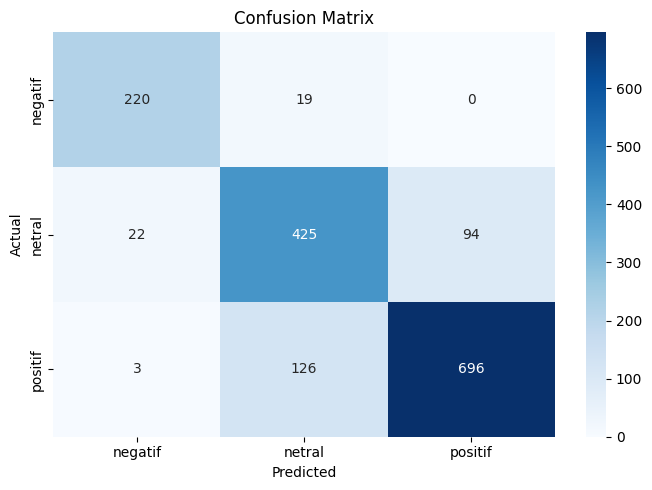

In [82]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_proba = model.predict(X_val_vec)
y_pred = np.argmax(y_pred_proba, axis=1)

label_names = ['negatif', 'netral', 'positif']
print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_val, y_pred, target_names=label_names))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

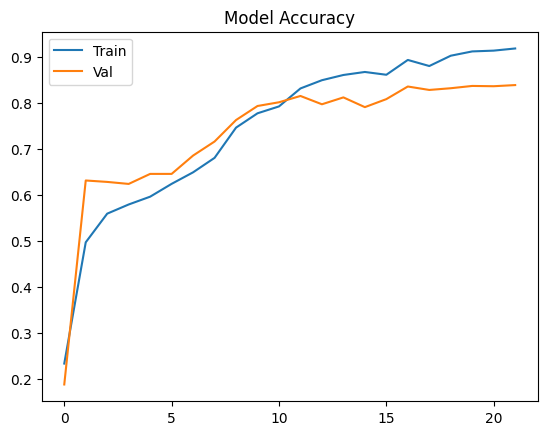

In [83]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Val'])
plt.show()

In [84]:
model.save("final_model.keras")
print("Model disimpan: final_model.keras")

model.export("saved_model/sentiment_model")
print("Model disimpan: saved_model/sentiment_model (SavedModel format)")

loaded_model = tf.saved_model.load("saved_model/sentiment_model")
print("SavedModel berhasil di-load dan siap untuk serving.")

Model disimpan: final_model.keras
Saved artifact at 'saved_model/sentiment_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100), dtype=tf.float32, name='input_text')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  140410538593744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140410538593360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140410538591824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140410538590480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140410538591248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140410538592592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140410235458896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140410538592976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140410235459856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140410538594128: TensorSpec(shape=(), dtype=tf.re

In [85]:
import re
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

_factory   = StopWordRemoverFactory()
_stopwords = _factory.get_stop_words()

_slang_dict = {
    "gk": "tidak", "ga": "tidak", "bgt": "banget",
    "yg": "yang",  "dgn": "dengan", "utk": "untuk",
    "krn": "karena", "sdh": "sudah", "blm": "belum",
    "jg": "juga",  "lg": "lagi",   "tp": "tapi",
}

def _preprocess(text: str) -> str:
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = ' '.join([_slang_dict.get(w, w) for w in text.split()])
    text = ' '.join([w for w in text.split() if w not in _stopwords])
    return text

def predict_sentiment(text: str) -> dict:
    """
    Inference pipeline lengkap.
    Input  : teks mentah (belum diproses)
    Output : dict berisi label, confidence, dan semua probabilitas
    """
    cleaned = _preprocess(text)

    vectorized = vectorizer([cleaned])

    proba = model.predict(vectorized, verbose=0)[0]
    label_idx = int(np.argmax(proba))

    mapping = {0: "negatif", 1: "netral", 2: "positif"}
    return {
        "input_asli"  : text,
        "teks_bersih" : cleaned,
        "sentimen"    : mapping[label_idx],
        "confidence"  : f"{proba[label_idx]*100:.2f}%",
        "probabilitas": {
            "negatif": f"{proba[0]*100:.2f}%",
            "netral" : f"{proba[1]*100:.2f}%",
            "positif": f"{proba[2]*100:.2f}%",
        }
    }

import pprint
pprint.pprint(predict_sentiment("acaranya seru dan sangat menyenangkan"))
pprint.pprint(predict_sentiment("servernya error terus, sangat mengecewakan"))
pprint.pprint(predict_sentiment("Biasa aja sih, ga ada yang spesial"))

{'confidence': '92.13%',
 'input_asli': 'acaranya seru dan sangat menyenangkan',
 'probabilitas': {'negatif': '0.00%', 'netral': '7.86%', 'positif': '92.13%'},
 'sentimen': 'positif',
 'teks_bersih': 'acaranya seru sangat menyenangkan'}
{'confidence': '99.92%',
 'input_asli': 'servernya error terus, sangat mengecewakan',
 'probabilitas': {'negatif': '99.92%', 'netral': '0.08%', 'positif': '0.00%'},
 'sentimen': 'negatif',
 'teks_bersih': 'servernya error terus sangat mengecewakan'}
{'confidence': '80.07%',
 'input_asli': 'Biasa aja sih, ga ada yang spesial',
 'probabilitas': {'negatif': '0.46%', 'netral': '80.07%', 'positif': '19.47%'},
 'sentimen': 'netral',
 'teks_bersih': 'biasa aja sih spesial'}


In [86]:
import numpy as np

inputs_gt = tf.keras.Input(shape=(100,), name='input_text')
x_gt = layers.Embedding(input_dim=10000, output_dim=128)(inputs_gt)
x_gt = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x_gt)
x_gt = AttentionLayer()(x_gt)
x_gt = layers.Dense(64, activation='relu')(x_gt)
x_gt = layers.Dropout(0.5)(x_gt)
outputs_gt = layers.Dense(3, activation='softmax')(x_gt)
model_gt = tf.keras.Model(inputs=inputs_gt, outputs=outputs_gt, name='sentiment_model_gradienttape')

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
loss_fn   = tf.keras.losses.SparseCategoricalCrossentropy()

train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
val_acc_metric   = tf.keras.metrics.SparseCategoricalAccuracy()

BATCH_SIZE = 32
EPOCHS     = 5

train_dataset = tf.data.Dataset.from_tensor_slices((X_train_vec, y_train)) \
                    .shuffle(1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset   = tf.data.Dataset.from_tensor_slices((X_val_vec, y_val)) \
                    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Memulai custom training loop dengan tf.GradientTape...\n")
history_gt = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    epoch_loss = []

    for step, (x_batch, y_batch) in enumerate(train_dataset):
        with tf.GradientTape() as tape:
            y_pred = model_gt(x_batch, training=True)
            loss   = loss_fn(y_batch, y_pred)

        gradients = tape.gradient(loss, model_gt.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model_gt.trainable_variables))

        train_acc_metric.update_state(y_batch, y_pred)
        epoch_loss.append(loss.numpy())

    train_loss = np.mean(epoch_loss)
    train_acc  = train_acc_metric.result().numpy()
    train_acc_metric.reset_state()

    val_losses = []
    for x_batch, y_batch in val_dataset:
        y_pred = model_gt(x_batch, training=False)
        val_losses.append(loss_fn(y_batch, y_pred).numpy())
        val_acc_metric.update_state(y_batch, y_pred)

    val_loss = np.mean(val_losses)
    val_acc  = val_acc_metric.result().numpy()
    val_acc_metric.reset_state()

    history_gt['train_loss'].append(train_loss)
    history_gt['train_acc'].append(train_acc)
    history_gt['val_loss'].append(val_loss)
    history_gt['val_acc'].append(val_acc)

    print(f"  loss: {train_loss:.4f} - acc: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

print("\nCustom training loop selesai!")

Memulai custom training loop dengan tf.GradientTape...

Epoch 1/5
  loss: 0.9126 - acc: 0.5484 - val_loss: 0.6803 - val_acc: 0.6399
Epoch 2/5
  loss: 0.5801 - acc: 0.7519 - val_loss: 0.4336 - val_acc: 0.8349
Epoch 3/5
  loss: 0.3091 - acc: 0.8936 - val_loss: 0.3763 - val_acc: 0.8623
Epoch 4/5
  loss: 0.1876 - acc: 0.9408 - val_loss: 0.3592 - val_acc: 0.8941
Epoch 5/5
  loss: 0.1219 - acc: 0.9645 - val_loss: 0.3750 - val_acc: 0.8991

Custom training loop selesai!
